# Building a Single-Cell Transcriptomic Aging Clock

This notebook accompanies the NeuroMethods chapter on biological age prediction using single-cell transcriptomics data.

This notebook utilizes a subset of real mouse subventricular zone single-cell RNA-seq data from *Buckely et al., 2022* to demonstrate the major steps of building a singe-cell transcriptomic aging clock.

The following steps are demonstrated in this notebook.
1. Load raw single-cell count data and metadata.
2. Aggregate single cells into BootstrapCells.
3. Normalize raw RNA counts.
4. Train a LASSO linear regression aging clock model.
5. Evaluate model performance.
6. Interpret the model coefficients.

## How to run this notebook

This notebook is intended to be run locally in JupyterLab, VS Code, or another Jupyter-compatible IDE after installing the required Python environment.

Recommended setup options are provided in the repository `README.md`, `environment.yml`, and `requirements.txt` files.

## 1. Load Python packages

First, we load the Python packages used in this notebook.

These packages help us work with tables, sparse single-cell count matrices, numerical arrays, and plots.

In [10]:
# Import pandas to work with tables
import pandas as pd

# Import numpy to work with numerical arrays
import numpy as np

# Inport scipy.sparse to work with sparse matrices
import scipy.sparse as sp

# Import matplotlib.pyplot to make plots
import matplotlib.pyplot as plt

# Import AnnData and Scanpy for standard single-cell data handling
import anndata as ad
import scanpy as sc

print("Packages loaded successfully.")

Packages loaded successfully.


## 2. Load the single-cell RNA-seq dataset

Next, we load a subset of the mouse subventricular zone single-cell RNA-seq data.

For this demo, the example dataset includes two cell types.
- Oligodendrocytes
- Microglia

In [11]:
# Folder containing the demo dataset
data_dir = "../data/svz_oligodendro_microglia_counts"

# Cell-level metadata
metadata = pd.read_csv(f"{data_dir}/cell_metadata.csv")

# Gene names and identifiers
genes = pd.read_csv(f"{data_dir}/genes.csv")

# Cell identifiers
cells = pd.read_csv(f"{data_dir}/cells.csv")

# Raw RNA count matrix
# Rows are genes, columns are cells
counts = sp.load_npz(f"{data_dir}/rna_counts_all_genes.npz")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [12]:
# Create an AnnData object for standard single-cell data handling.
# AnnData stores cells as rows and genes as columns, so we transpose the count matrix.

obs = metadata.copy()
obs.index = obs["cell_id"].astype(str)

var = genes.copy()
var.index = var["gene_name"].astype(str)

adata = ad.AnnData(
    X=counts.T.tocsr(),
    obs=obs,
    var=var
)

# Ensure gene names are unique, which AnnData/Scanpy expects.
adata.var_names_make_unique()

# Store the raw count matrix before later normalization.
adata.layers["counts"] = adata.X.copy()

print(adata)

AnnData object with n_obs × n_vars = 9787 × 31053
    obs: 'cell_id', 'mouse_id', 'age_months', 'batch', 'cell_type', 'nCount_RNA', 'nFeature_RNA', 'UMAP_1', 'UMAP_2', 'UMAP_harmony_1', 'UMAP_harmony_2'
    var: 'gene_id', 'gene_name'
    layers: None (.X), 'counts'


## 3. Inspect and QC-check the modeling input

This demo starts from a processed, cell-type-annotated single-cell RNA-seq dataset from the *Buckely et al., 2022* SVZ aging clock paper.

Major preprocessing steps such as initial cell filtering, integration, clustering, and cell-type annotation were performed upstream. Here, we perform a few simple checks on the data before creating BootstrapCells.

We check
1. Whether the metadata rows match the count-matrix columns.
2. Whether the matrix dimensions match the gene and cell tables.
3. Whether the raw count totals match the metadata.
4. How many cells are available for each cell type and mouse.
5. Whether the data show expected structure in visualizations.

In [13]:
# The count matrix should have genes as rows and cells as columns
n_genes, n_cells = counts.shape

# Calculate the total raw RNA counts detected in each cell
library_size = np.asarray(counts.sum(axis=0)).ravel()

# Check whether metadata and count matrix are aligned
cell_order_matches = metadata["cell_id"].tolist() == cells["cell_id"].tolist()

# Check whether matrix dimensions match the metadata and gene tables
cell_number_matches = counts.shape[1] == metadata.shape[0]
gene_number_matches = counts.shape[0] == genes.shape[0]

# Check whether matrix column sums match the raw count totals in the metadata
raw_counts_match_metadata = np.allclose(
    library_size,
    metadata["nCount_RNA"].to_numpy()
)

qc_summary = pd.DataFrame({
    "QC check": [
        "Metadata cell order matches cells table",
        "Number of matrix columns matches metadata rows",
        "Number of matrix rows matches gene table rows",
        "Matrix column sums match nCount_RNA metadata",
        "All cells have nonzero raw counts"
    ],
    "Result": [
        cell_order_matches,
        cell_number_matches,
        gene_number_matches,
        raw_counts_match_metadata,
        np.all(library_size > 0)
    ]
})

qc_summary

,QC check,Result
0,Metadata cell order matches cells table,True
1,Number of matrix columns matches metadata rows,True
2,Number of matrix rows matches gene table rows,True
3,Matrix column sums match nCount_RNA metadata,True
4,All cells have nonzero raw counts,True


In [14]:
# Dataset summary
dataset_summary = pd.DataFrame({
    "Quantity": [
        "Number of genes",
        "Number of cells",
        "Number of mice",
        "Youngest mouse age",
        "Oldest mouse age",
        "Median raw counts per cell",
        "Median detected genes per cell"
    ],
    "Value": [
        f"{n_genes:,}",
        f"{n_cells:,}",
        metadata["mouse_id"].nunique(),
        f"{metadata['age_months'].min():.1f} months",
        f"{metadata['age_months'].max():.1f} months",
        f"{np.median(metadata['nCount_RNA']):,.0f}",
        f"{np.median(metadata['nFeature_RNA']):,.0f}"
    ]
})

dataset_summary

,Quantity,Value
0,Number of genes,"31,053"
1,Number of cells,"9,787"
2,Number of mice,28
3,Youngest mouse age,3.3 months
4,Oldest mouse age,29.0 months
5,Median raw counts per cell,"5,143"
6,Median detected genes per cell,"2,013"


In [15]:
# Count how many cells and mice are available for each cell type
cell_availability = (
    metadata
    .groupby("cell_type")
    .agg(
        Number_of_mice=("mouse_id", "nunique"),
        Total_number_of_cells=("cell_id", "count")
    )
    .reset_index()
)

# Rename columns to make the table easier to read
cell_availability.columns = [
    "Cell type",
    "Number of mice",
    "Total number of cells"
]

cell_availability

,Cell type,Number of mice,Total number of cells
0,Microglia,28,3844
1,Oligodendro,28,5943


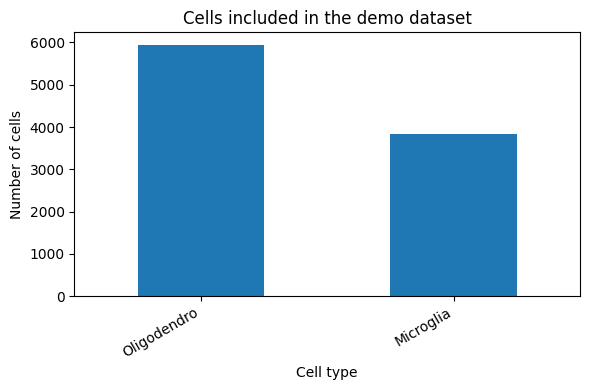

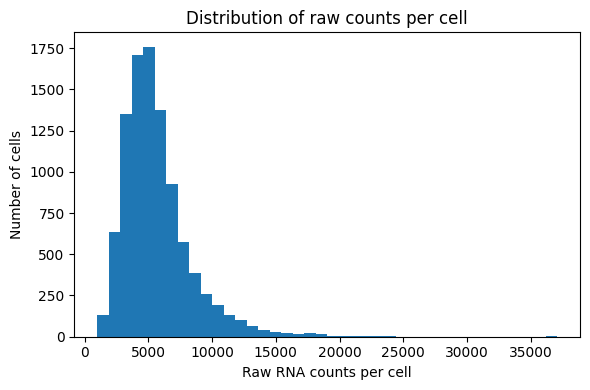

In [16]:
# Make plots of simple QC
plt.rcParams["figure.figsize"] = (6, 4)

# Plot 1: number of cells per cell type
cell_type_counts = metadata["cell_type"].value_counts()

plt.figure()
cell_type_counts.plot(kind="bar")
plt.ylabel("Number of cells")
plt.xlabel("Cell type")
plt.title("Cells included in the demo dataset")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Plot 2: raw count totals per cell
plt.figure()
plt.hist(library_size, bins=40)
plt.xlabel("Raw RNA counts per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of raw counts per cell")
plt.tight_layout()
plt.show()

### Visualize the cells with UMAP

The processed Seurat object includes UMAP coordinates from the upstream single-cell analysis.

Here, we use the Harmony-based UMAP coordinates to visualize the cells included in this demo. These plots help us see how the selected cells relate to cell type, mouse age, and sequencing batch before we build the aging clock.

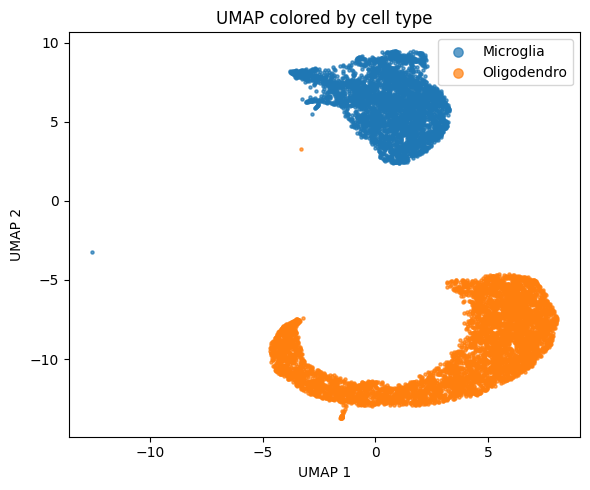

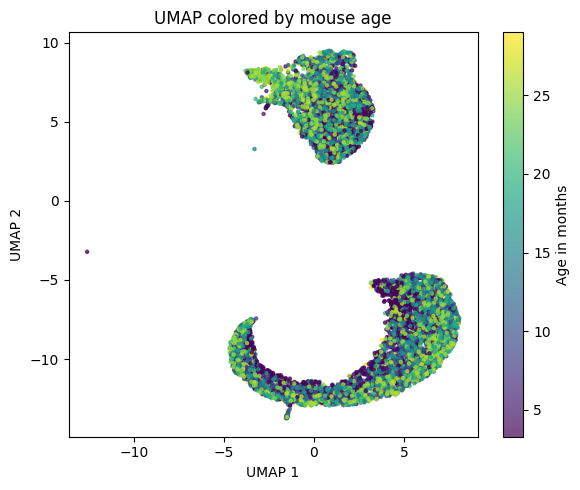

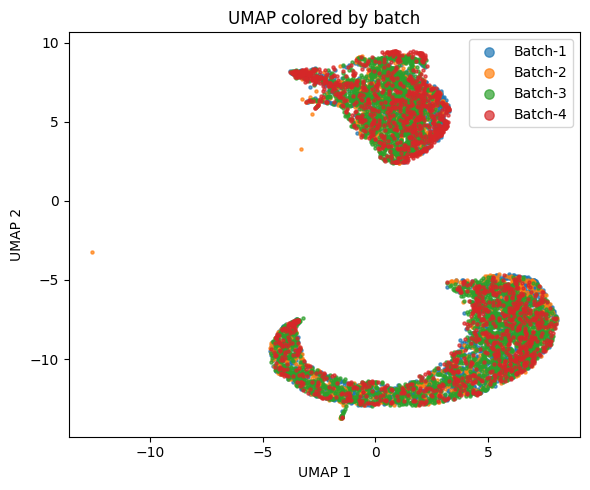

In [17]:
# Use the Harmony-based UMAP coordinates from the upstream analysis
umap_x = "UMAP_harmony_1"
umap_y = "UMAP_harmony_2"

# Plot 1: UMAP colored by cell type
plt.figure(figsize=(6, 5))

for cell_type, table in metadata.groupby("cell_type"):
    plt.scatter(
        table[umap_x],
        table[umap_y],
        s=5,
        alpha=0.7,
        label=cell_type
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP colored by cell type")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()


# Plot 2: UMAP colored by mouse age
plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    metadata[umap_x],
    metadata[umap_y],
    c=metadata["age_months"],
    s=5,
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP colored by mouse age")
plt.colorbar(scatter, label="Age in months")
plt.tight_layout()
plt.show()


# Plot 3: UMAP colored by batch
plt.figure(figsize=(6, 5))

for batch, table in metadata.groupby("batch"):
    plt.scatter(
        table[umap_x],
        table[umap_y],
        s=5,
        alpha=0.7,
        label=batch
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP colored by batch")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 4. Create BootstrapCells

The *Buckely et al., 2022* SVZ aging clock workflow used **BootstrapCells** as the modeling unit.
A BootstrapCell is created by sampling a small group of cells from the same mouse and the same cell type, then summing their raw RNA counts. This creates a pseudobulk-like expression profile that is less noisy than an individual single-cell profile but averages across less cells than conventional pseudobulk approaches.

In this demo, we create BootstrapCells separately for two cell types, oligodendrocytes and microglia.

The original SVZ workflow used 15 cells per BootstrapCell and generated 100 BootstrapCells per mouse and cell type. We use the same settings here.

In [18]:
# Cell types for this demo
cell_types_to_model = ["Oligodendro", "Microglia"]

# each BootstrapCell is created from 15 sampled cells.
bootstrap_size = 15

# create 100 BootstrapCells per mouse and cell type.
n_bootstrap_per_mouse = 100

# Set a random seed so the same BootstrapCells are created each time.
rng = np.random.default_rng(42)

# These lists will store the new BootstrapCell count profiles and metadata.
bootstrap_count_columns = []
bootstrap_metadata_rows = []

# Create BootstrapCells separately for each cell type.
for cell_type in cell_types_to_model:
    cells_this_type = metadata[metadata["cell_type"] == cell_type]
    # Within this cell type, create BootstrapCells separately for each mouse.
    for mouse_id, mouse_cells in cells_this_type.groupby("mouse_id"):
        # These are the column positions of this mouse's cells in the count matrix.
        cell_indices = mouse_cells.index.to_numpy()
        # Mouse-level information that will be stored for each BootstrapCell.
        age = mouse_cells["age_months"].iloc[0]
        batch = mouse_cells["batch"].iloc[0]
        n_available_cells = len(cell_indices)
        # sample with replacement only if there are not enough cells.
        replace = n_available_cells <= bootstrap_size
        # Create repeated BootstrapCells for this mouse and cell type.
        for i in range(n_bootstrap_per_mouse):
            # Randomly sample cells from this mouse and cell type.
            sampled_indices = rng.choice(
                cell_indices,
                size=bootstrap_size,
                replace=replace
            )
            # Sum raw counts across the sampled cells to create one BootstrapCell expression profile.
            one_bootstrap_count = counts[:, sampled_indices].sum(axis=1)
            # Store this BootstrapCell as one column
            bootstrap_count_columns.append(sp.csc_matrix(one_bootstrap_count))
            # Store metadata for this BootstrapCell
            bootstrap_metadata_rows.append({
                "bootstrap_id": f"{mouse_id}_{cell_type}_bootstrap_{i + 1}",
                "mouse_id": mouse_id,
                "age_months": age,
                "batch": batch,
                "cell_type": cell_type,
                "n_cells_sampled": bootstrap_size,
                "n_available_cells": n_available_cells
            })
# Combine all BootstrapCells into one sparse matrix where rows are genes and columns are BootstrapCells
bootstrap_counts = sp.hstack(bootstrap_count_columns).tocsc()

# Create a metadata table for the BootstrapCells
bootstrap_metadata = pd.DataFrame(bootstrap_metadata_rows)

print("BootstrapCells created successfully.")
print("BootstrapCell count matrix:", bootstrap_counts.shape)
print("BootstrapCell metadata table:", bootstrap_metadata.shape)

BootstrapCells created successfully.
BootstrapCell count matrix: (31053, 5600)
BootstrapCell metadata table: (5600, 7)


In [19]:
# Summarize how many BootstrapCells were created for each cell type
bootstrap_summary = (
    bootstrap_metadata
    .groupby("cell_type")
    .agg(
        Number_of_mice=("mouse_id", "nunique"),
        Number_of_BootstrapCells=("bootstrap_id", "count"),
        Cells_per_BootstrapCell=("n_cells_sampled", "first")
    )
    .reset_index()
)

bootstrap_summary.columns = [
    "Cell type",
    "Number of mice",
    "Number of BootstrapCells",
    "Cells per BootstrapCell"
]

bootstrap_summary

,Cell type,Number of mice,Number of BootstrapCells,Cells per BootstrapCell
0,Microglia,28,2800,15
1,Oligodendro,28,2800,15


In [20]:
# Preview the BootstrapCell metadata, where each row describes one BootstrapCell
bootstrap_metadata.head()

,bootstrap_id,mouse_id,age_months,batch,cell_type,n_cells_sampled,n_available_cells
0,BC1-3.30-TGTGATGG_Oligodendro_bootstrap_1,BC1-3.30-TGTGATGG,3.3,Batch-3,Oligodendro,15,405
1,BC1-3.30-TGTGATGG_Oligodendro_bootstrap_2,BC1-3.30-TGTGATGG,3.3,Batch-3,Oligodendro,15,405
2,BC1-3.30-TGTGATGG_Oligodendro_bootstrap_3,BC1-3.30-TGTGATGG,3.3,Batch-3,Oligodendro,15,405
3,BC1-3.30-TGTGATGG_Oligodendro_bootstrap_4,BC1-3.30-TGTGATGG,3.3,Batch-3,Oligodendro,15,405
4,BC1-3.30-TGTGATGG_Oligodendro_bootstrap_5,BC1-3.30-TGTGATGG,3.3,Batch-3,Oligodendro,15,405


## 5. Normalize BootstrapCell counts

Each BootstrapCell was created by summing raw RNA counts from 15 sampled cells.

However, different BootstrapCells can have different total numbers of RNA counts. Before training an aging clock, we normalize each BootstrapCell to the same total count scale and then apply a log transform.

Here, we use the following normalization approach:
1. Count the total RNA molecules in each BootstrapCell.
2. Scale each BootstrapCell to 10,000 total counts.
3. Apply a log transform.

The result is a log-normalized BootstrapCell expression matrix that we will use for clock training.

In [21]:
# Calculate the total raw RNA counts in each BootstrapCell
bootstrap_library_size = np.asarray(
    bootstrap_counts.sum(axis=0)
).ravel()

# Create an AnnData object for the BootstrapCells.
# AnnData stores observations as rows, so we transpose the matrix.
bootstrap_obs = bootstrap_metadata.copy()
bootstrap_obs.index = bootstrap_obs["bootstrap_id"].astype(str)

bootstrap_adata = ad.AnnData(
    X=bootstrap_counts.T.tocsr(),
    obs=bootstrap_obs,
    var=adata.var.copy()
)

# Store the raw BootstrapCell counts before normalization.
bootstrap_adata.layers["counts"] = bootstrap_adata.X.copy()

# Normalize each BootstrapCell to the same total count scale.
scale_factor = 10_000
sc.pp.normalize_total(bootstrap_adata, target_sum=scale_factor)

# Log-transform the normalized counts.
sc.pp.log1p(bootstrap_adata)

# Keep the same genes × BootstrapCells matrix format used later in the notebook.
log_bootstrap_counts = bootstrap_adata.X.T.tocsc()

print("BootstrapCell counts normalized successfully.")
print("Log-normalized matrix:", log_bootstrap_counts.shape)

BootstrapCell counts normalized successfully.
Log-normalized matrix: (31053, 5600)


In [22]:
# Add raw library size to the BootstrapCell metadata
bootstrap_metadata["raw_counts_per_BootstrapCell"] = bootstrap_library_size

# Create a summary table
normalization_summary = pd.DataFrame({
    "Quantity": [
        "Number of BootstrapCells",
        "Median raw counts per BootstrapCell",
        "Minimum raw counts per BootstrapCell",
        "Maximum raw counts per BootstrapCell",
        "Normalization target",
        "Log-normalized matrix"
    ],
    "Value": [
        f"{bootstrap_metadata.shape[0]:,}",
        f"{np.median(bootstrap_library_size):,.0f}",
        f"{np.min(bootstrap_library_size):,.0f}",
        f"{np.max(bootstrap_library_size):,.0f}",
        f"{scale_factor:,} counts per BootstrapCell",
        f"{log_bootstrap_counts.shape[0]:,} genes x {log_bootstrap_counts.shape[1]:,} BootstrapCells"
    ]
})

normalization_summary

,Quantity,Value
0,Number of BootstrapCells,"5,600"
1,Median raw counts per BootstrapCell,"90,850"
2,Minimum raw counts per BootstrapCell,"41,695"
3,Maximum raw counts per BootstrapCell,"199,249"
4,Normalization target,"10,000 counts per BootstrapCell"
5,Log-normalized matrix,"31,053 genes x 5,600 BootstrapCells"


## 6. Train cell-type-specific LASSO aging clocks

Now we train transcriptomic aging clocks using the log-normalized BootstrapCell expression matrix.

We train two separate cell-type-specific clocks, one for oligodendrocytes and one for microglia.

For this demo, we use a **LASSO regression model**.

We first select a set of highly variable genes within each training split.

Then, to validate the clocks, we use a leave-one-batch-out strategy, where we
1. Hold out one sequencing batch.
2. Train the LASSO clock using the other batches.
3. Predict age and calculate metrics for BootstrapCells in the held-out batch.
4. Repeat until each batch has been held out once.

In [49]:
# Import LASSO regression model with internal cross-validation
from sklearn.linear_model import LassoCV

In [50]:
# We will train one LASSO aging clock for each cell type.
cell_types_to_model = ["Oligodendro", "Microglia"]

# Use the most variable genes from the training data for each cell type and held-out batch.
n_genes_for_clock = 500

# Candidate LASSO penalty strengths.
# LassoCV will choose one of these values using cross-validation.
lasso_alphas = np.logspace(-3, 0, 25)

# Lists to store results.
prediction_tables = []
model_summary_rows = []

# Train and evaluate one clock per cell type.
for cell_type in cell_types_to_model:
    print(f"Training {cell_type} LASSO clock")
    # Work only with BootstrapCells from this cell type.
    cell_type_mask = bootstrap_metadata["cell_type"] == cell_type
    # Hold out each batch once.
    for held_out_batch in sorted(bootstrap_metadata["batch"].unique()):
        print(f"  Holding out {held_out_batch}")
        # Training BootstrapCells
        train_mask = (
            cell_type_mask &
            (bootstrap_metadata["batch"] != held_out_batch)
        )
        # Test BootstrapCells
        test_mask = (
            cell_type_mask &
            (bootstrap_metadata["batch"] == held_out_batch)
        )
        train_indices = np.where(train_mask)[0]
        test_indices = np.where(test_mask)[0]

        # Select highly variable genes using only the training data.        
        train_matrix = log_bootstrap_counts[:, train_indices]
        
        gene_mean = np.asarray(train_matrix.mean(axis=1)).ravel()
        gene_mean_squared = np.asarray(train_matrix.power(2).mean(axis=1)).ravel()
        gene_variance = gene_mean_squared - gene_mean**2
        
        selected_gene_indices = np.argsort(gene_variance)[-n_genes_for_clock:]
        
        # Build model input matrices.
        # X = gene expression values
        # y = chronological age in months
        
        X_train = (
            log_bootstrap_counts[selected_gene_indices, :][:, train_indices]
            .T
            .toarray()
        )
        
        X_test = (
            log_bootstrap_counts[selected_gene_indices, :][:, test_indices]
            .T
            .toarray()
        )
        
        y_train = bootstrap_metadata.iloc[train_indices]["age_months"].to_numpy()
        y_test = bootstrap_metadata.iloc[test_indices]["age_months"].to_numpy()
        
        # Train pure LASSO regression with an L1 penalty.
        # LassoCV selects the LASSO penalty using cross-validation.
        
        lasso_model = LassoCV(
            alphas=lasso_alphas,
            cv=5,
            max_iter=5000,
            random_state=42
        )
        
        lasso_model.fit(X_train, y_train)
        
        # Predict age for the held-out batch.
        
        predicted_age = lasso_model.predict(X_test)
        
        # Store predictions.
        prediction_table = bootstrap_metadata.iloc[test_indices].copy()
        prediction_table["held_out_batch"] = held_out_batch
        prediction_table["predicted_age_months"] = predicted_age
        
        prediction_tables.append(prediction_table)
        
        # Store a compact model summary.
        model_summary_rows.append({
            "cell_type": cell_type,
            "held_out_batch": held_out_batch,
            "training_BootstrapCells": len(train_indices),
            "test_BootstrapCells": len(test_indices),
            "genes_used": n_genes_for_clock,
            "selected_alpha": lasso_model.alpha_,
            "nonzero_gene_coefficients": np.sum(lasso_model.coef_ != 0)
        })

# Combine results from all cell types and held-out batches.
clock_predictions = pd.concat(prediction_tables, ignore_index=True)
lasso_model_summary = pd.DataFrame(model_summary_rows)

print("Finished training cell-type-specific LASSO clocks.")

Training Oligodendro LASSO clock
  Holding out Batch-1
  Holding out Batch-2
  Holding out Batch-3
  Holding out Batch-4
Training Microglia LASSO clock
  Holding out Batch-1
  Holding out Batch-2
  Holding out Batch-3
  Holding out Batch-4
Finished training cell-type-specific LASSO clocks.


In [19]:
# View LASSO model summary

lasso_model_summary

,cell_type,held_out_batch,training_BootstrapCells,test_BootstrapCells,genes_used,selected_alpha,nonzero_gene_coefficients
0,Oligodendro,Batch-1,2400,400,500,0.042170,64
1,Oligodendro,Batch-2,2000,800,500,0.042170,54
2,Oligodendro,Batch-3,2000,800,500,0.177828,11
3,Oligodendro,Batch-4,2000,800,500,0.177828,10
4,Microglia,Batch-1,2400,400,500,0.074989,55
5,Microglia,Batch-2,2000,800,500,0.042170,76
6,Microglia,Batch-3,2000,800,500,0.133352,33
7,Microglia,Batch-4,2000,800,500,0.177828,19


In [20]:
# Preview predictions

clock_predictions[
    [
        "bootstrap_id",
        "mouse_id",
        "age_months",
        "batch",
        "cell_type",
        "held_out_batch",
        "predicted_age_months"
    ]
].head()

,bootstrap_id,mouse_id,age_months,batch,cell_type,held_out_batch,predicted_age_months
0,Sample1-TGTGATGG_Oligodendro_bootstrap_1,Sample1-TGTGATGG,4.7,Batch-1,Oligodendro,Batch-1,3.520075
1,Sample1-TGTGATGG_Oligodendro_bootstrap_2,Sample1-TGTGATGG,4.7,Batch-1,Oligodendro,Batch-1,4.953736
2,Sample1-TGTGATGG_Oligodendro_bootstrap_3,Sample1-TGTGATGG,4.7,Batch-1,Oligodendro,Batch-1,1.997068
3,Sample1-TGTGATGG_Oligodendro_bootstrap_4,Sample1-TGTGATGG,4.7,Batch-1,Oligodendro,Batch-1,-0.066988
4,Sample1-TGTGATGG_Oligodendro_bootstrap_5,Sample1-TGTGATGG,4.7,Batch-1,Oligodendro,Batch-1,1.566632


## 7. Evaluate the LASSO aging clocks

Now we evaluate the performance of each cell-type-specific LASSO clock. We use only held out batches to evaluate performance.

For each cell type, we compare:

- **Chronological age**: the true age of the mouse.
- **Predicted age**: the age predicted from BootstrapCell gene expression.

We calculate two performance metrics:

- **Mean absolute error (MAE)**: the average absolute difference between predicted age and chronological age.
- **Pearson correlation (r)**: how strongly predicted age and chronological age are linearly related.

We also visualize the predictions. Each small point is one held-out BootstrapCell. The larger open circles show the mean prediction for each mouse.

In [21]:
# Calculate absolute prediction error for each BootstrapCell.
clock_predictions["absolute_error"] = abs(
    clock_predictions["predicted_age_months"] - clock_predictions["age_months"]
)

# Summarize performance at the BootstrapCell level.
bootstrap_metrics = (
    clock_predictions
    .groupby("cell_type")
    .apply(
        lambda table: pd.Series({
            "BootstrapCell MAE": table["absolute_error"].mean(),
            "BootstrapCell Pearson r": np.corrcoef(
                table["age_months"],
                table["predicted_age_months"]
            )[0, 1]
        })
    )
    .reset_index()
)

bootstrap_metrics

,cell_type,BootstrapCell MAE,BootstrapCell Pearson r
0,Microglia,3.184027,0.866723
1,Oligodendro,2.966241,0.882002


In [22]:
# Average predictions across BootstrapCells from the same mouse and cell type.
# This gives one mean predicted age per mouse for each cell type.
mouse_predictions = (
    clock_predictions
    .groupby(["cell_type", "mouse_id", "age_months"])
    .agg(
        mean_predicted_age=("predicted_age_months", "mean"),
        n_BootstrapCells=("bootstrap_id", "count")
    )
    .reset_index()
)

# Calculate mouse-level error.
mouse_predictions["absolute_error"] = abs(
    mouse_predictions["mean_predicted_age"] - mouse_predictions["age_months"]
)

# Summarize performance at the mouse level.
mouse_metrics = (
    mouse_predictions
    .groupby("cell_type")
    .apply(
        lambda table: pd.Series({
            "Mouse-level MAE": table["absolute_error"].mean(),
            "Mouse-level Pearson r": np.corrcoef(
                table["age_months"],
                table["mean_predicted_age"]
            )[0, 1]
        })
    )
    .reset_index()
)

mouse_metrics

,cell_type,Mouse-level MAE,Mouse-level Pearson r
0,Microglia,2.755354,0.907163
1,Oligodendro,2.579370,0.914547


In [23]:
# Combine BootstrapCell-level and mouse-level metrics.
clock_metrics = pd.merge(
    bootstrap_metrics,
    mouse_metrics,
    on="cell_type"
)

# Round values for display.
clock_metrics_rounded = clock_metrics.copy()

for column in clock_metrics_rounded.columns:
    if column != "cell_type":
        clock_metrics_rounded[column] = clock_metrics_rounded[column].round(3)

clock_metrics_rounded.columns = [
    "Cell type",
    "BootstrapCell MAE",
    "BootstrapCell Pearson r",
    "Mouse-level MAE",
    "Mouse-level Pearson r"
]

clock_metrics_rounded

,Cell type,BootstrapCell MAE,BootstrapCell Pearson r,Mouse-level MAE,Mouse-level Pearson r
0,Microglia,3.184,0.867,2.755,0.907
1,Oligodendro,2.966,0.882,2.579,0.915


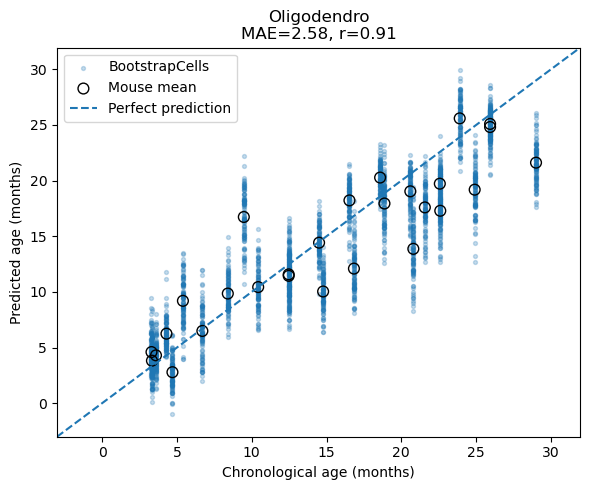

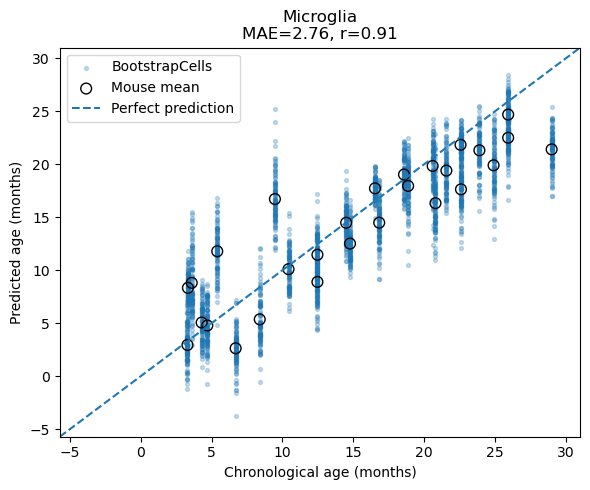

In [24]:
# Plot predicted age versus chronological age for each cell-type-specific clock.

cell_types_to_plot = ["Oligodendro", "Microglia"]

for cell_type in cell_types_to_plot:
    
    # BootstrapCell-level predictions for this cell type.
    bootstrap_table = clock_predictions[
        clock_predictions["cell_type"] == cell_type
    ]
    
    # Mouse-level mean predictions for this cell type.
    mouse_table = mouse_predictions[
        mouse_predictions["cell_type"] == cell_type
    ]
    
    # Get mouse-level metrics for the plot title.
    metric_row = clock_metrics[
        clock_metrics["cell_type"] == cell_type
    ].iloc[0]
    
    mae = metric_row["Mouse-level MAE"]
    r = metric_row["Mouse-level Pearson r"]
    
    # Set plot limits.
    min_age = min(
        bootstrap_table["age_months"].min(),
        bootstrap_table["predicted_age_months"].min()
    )
    
    max_age = max(
        bootstrap_table["age_months"].max(),
        bootstrap_table["predicted_age_months"].max()
    )
    
    padding = 2
    plot_min = min_age - padding
    plot_max = max_age + padding
    
    # Make the plot.
    plt.figure(figsize=(6, 5))
    
    # Small points: individual BootstrapCell predictions.
    plt.scatter(
        bootstrap_table["age_months"],
        bootstrap_table["predicted_age_months"],
        s=8,
        alpha=0.25,
        label="BootstrapCells"
    )
    
    # Larger open circles: mean prediction for each mouse.
    plt.scatter(
        mouse_table["age_months"],
        mouse_table["mean_predicted_age"],
        s=60,
        facecolors="none",
        edgecolors="black",
        label="Mouse mean"
    )
    
    # Dashed diagonal line: perfect prediction.
    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        label="Perfect prediction"
    )
    
    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    
    plt.xlabel("Chronological age (months)")
    plt.ylabel("Predicted age (months)")
    plt.title(f"{cell_type}\nMAE={mae:.2f}, r={r:.2f}")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

## 8. Train final LASSO clock for each cell type

In this section, we train one final LASSO clock for each cell type using all BootstrapCells from that cell type.

In [26]:
# Train one final LASSO model per cell type for gene inspection.
cell_types_to_model = ["Oligodendro", "Microglia"]

# Same number of variable genes
n_genes_for_final_clock = 500

# Candidate LASSO penalty strengths.
lasso_alphas = np.logspace(-3, 0, 25)

# Gene names from the genes table.
gene_names = genes.iloc[:, 0].astype(str).to_numpy()

# Store final model summaries and selected genes.
final_model_rows = []
final_gene_tables = []

for cell_type in cell_types_to_model:
    
    print(f"Training final {cell_type} LASSO clock")
    
    # Select BootstrapCells from this cell type.
    cell_type_mask = bootstrap_metadata["cell_type"] == cell_type
    cell_type_indices = np.where(cell_type_mask)[0]
    
    # Expression matrix for this cell type.
    matrix_this_type = log_bootstrap_counts[:, cell_type_indices]
    
    # Chronological age labels.
    y = bootstrap_metadata.iloc[cell_type_indices]["age_months"].to_numpy()
    
    # Select highly variable genes within this cell type.
    gene_mean = np.asarray(matrix_this_type.mean(axis=1)).ravel()
    gene_mean_squared = np.asarray(matrix_this_type.power(2).mean(axis=1)).ravel()
    gene_variance = gene_mean_squared - gene_mean**2
    
    selected_gene_indices = np.argsort(gene_variance)[-n_genes_for_final_clock:]
    
    # Build the model input matrix.
    # Rows are BootstrapCells, columns are selected genes.
    X = matrix_this_type[selected_gene_indices, :].T.toarray()
    
    # Train pure LASSO with internal cross-validation.
    final_lasso_model = LassoCV(
        alphas=lasso_alphas,
        cv=5,
        max_iter=5000,
        random_state=42
    )
    
    final_lasso_model.fit(X, y)
    
    # Store model-level information.
    final_model_rows.append({
        "cell_type": cell_type,
        "BootstrapCells used": X.shape[0],
        "Genes tested": X.shape[1],
        "Selected alpha": final_lasso_model.alpha_,
        "Nonzero genes": np.sum(final_lasso_model.coef_ != 0)
    })
    
    # Store gene coefficients.
    gene_table = pd.DataFrame({
        "cell_type": cell_type,
        "gene": gene_names[selected_gene_indices],
        "coefficient": final_lasso_model.coef_
    })
    
    # Keep only genes selected by LASSO.
    gene_table = gene_table[gene_table["coefficient"] != 0].copy()
    
    # Add absolute coefficient size for sorting.
    gene_table["absolute_coefficient"] = gene_table["coefficient"].abs()
    
    # Add a simple interpretation of coefficient direction.
    gene_table["direction"] = np.where(
        gene_table["coefficient"] > 0,
        "higher expression predicts older age",
        "higher expression predicts younger age"
    )
    
    final_gene_tables.append(gene_table)

# Combine results across cell types.
final_lasso_summary = pd.DataFrame(final_model_rows)
final_clock_genes = pd.concat(final_gene_tables, ignore_index=True)

print("Finished training final LASSO clocks.")

Training final Oligodendro LASSO clock
Training final Microglia LASSO clock
Finished training final LASSO clocks.


In [27]:
# View final model summary

final_lasso_summary

,cell_type,BootstrapCells used,Genes tested,Selected alpha,Nonzero genes
0,Oligodendro,2800,500,0.133352,19
1,Microglia,2800,500,0.100000,39


## 9. Inspect selected clock genes

We now inspect which genes were selected by the oligodendrocyte and microglia clocks.

A positive coefficient means that higher expression of that gene is associated with an older predicted age. A negative coefficient means that higher expression is associated with a younger predicted age.

These coefficients should be interpreted as model features, not as proof of causality of aging.

In [30]:
# Show the strongest positive and negative genes for each cell-type-specific clock.
top_n = 10

top_gene_tables = []

for cell_type in cell_types_to_model:
    
    genes_this_clock = final_clock_genes[
        final_clock_genes["cell_type"] == cell_type
    ].copy()
    
    # Positive coefficients:
    # higher expression pushes the model toward older predicted age.
    top_positive = (
        genes_this_clock
        .sort_values("coefficient", ascending=False)
        .head(top_n)
        .copy()
    )
    
    top_positive["coefficient_group"] = "Top positive coefficients"
    
    # Negative coefficients:
    # higher expression pushes the model toward younger predicted age.
    top_negative = (
        genes_this_clock
        .sort_values("coefficient", ascending=True)
        .head(top_n)
        .copy()
    )
    
    top_negative["coefficient_group"] = "Top negative coefficients"
    
    top_gene_tables.append(top_positive)
    top_gene_tables.append(top_negative)

top_clock_genes = pd.concat(top_gene_tables, ignore_index=True)

top_clock_genes[
    ["cell_type", "coefficient_group", "gene", "coefficient", "direction"]
]

,cell_type,coefficient_group,gene,coefficient,direction
0,Oligodendro,Top positive coefficients,C4b,7.182258,higher expression predicts older age
1,Oligodendro,Top positive coefficients,Apoe,3.759649,higher expression predicts older age
2,Oligodendro,Top positive coefficients,Gstm1,2.305480,higher expression predicts older age
3,Oligodendro,Top positive coefficients,Ndrg2,1.895684,higher expression predicts older age
4,Oligodendro,Top positive coefficients,H2-D1,1.686178,higher expression predicts older age
5,Oligodendro,Top positive coefficients,Abca8a,1.399946,higher expression predicts older age
6,Oligodendro,Top positive coefficients,Pmp22,0.952150,higher expression predicts older age
7,Oligodendro,Top positive coefficients,Hopx,0.831631,higher expression predicts older age
8,Oligodendro,Top positive coefficients,Gstp1,0.533764,higher expression predicts older age
9,Oligodendro,Top positive coefficients,Pou3f1,0.395846,higher expression predicts older age


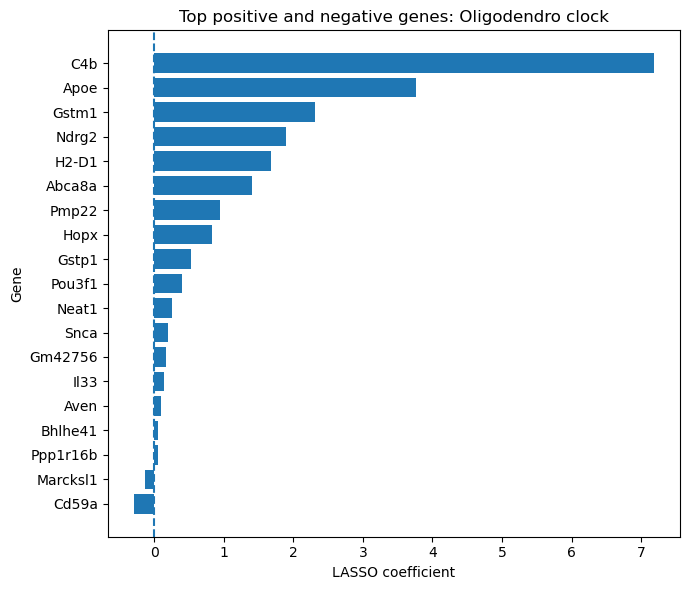

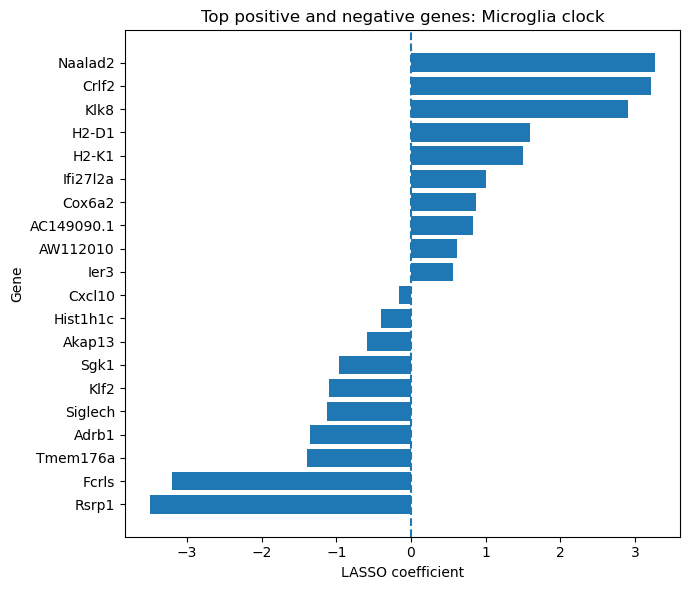

In [31]:
# Plot the strongest positive and negative genes for each clock.

for cell_type in cell_types_to_model:
    
    plot_table = top_clock_genes[
        top_clock_genes["cell_type"] == cell_type
    ].copy()
    
    # Sort so negative genes appear on one side and positive genes on the other.
    plot_table = plot_table.sort_values("coefficient")
    
    plt.figure(figsize=(7, 6))
    
    plt.barh(
        plot_table["gene"],
        plot_table["coefficient"]
    )
    
    plt.axvline(0, linestyle="--")
    plt.xlabel("LASSO coefficient")
    plt.ylabel("Gene")
    plt.title(f"Top positive and negative genes: {cell_type} clock")
    
    plt.tight_layout()
    plt.show()

## 10. Summary and interpretation

In this notebook, we walked through a simple version of a single-cell transcriptomic aging clock development workflow.

We started with processed, cell-type-annotated single-cell RNA-seq data from the mouse subventricular zone. We then
1. Loaded raw single-cell count data and metadata.
2. Inspected the modeling input and visualized cells using UMAP.
3. Created BootstrapCells by sampling cells from the same mouse and cell type.
4. Normalized BootstrapCell count profiles.
5. Trained separate LASSO aging clocks for oligodendrocytes and microglia.
6. Evaluated clock performance using predicted age, chronological age, MAE, and Pearson correlation.
7. Inspected genes selected by the LASSO models.